In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import random

In [2]:
# Parameters
n = 200
K = 3
π = np.array([0.5, 0.15, 0.35])

In [3]:
np.random.seed(1)

# Generate community membership Θ matrix
Θ = np.random.multinomial(1, π, size=n)

# Calculate the observed number of members for each community
observed_members = Θ.sum(axis=0)
sorted_Θ = np.sort(Θ, axis=0)

# Print the expected and observed number of members for each community
print("Expected number of members for each community:")
for k in range(K):
    print(f"Community {k+1}: {n * π[k]}")

print("\nObserved number of members for each community:")
for k in range(K):
    print(f"Community {k+1}: {observed_members[k]}")

Expected number of members for each community:
Community 1: 100.0
Community 2: 30.0
Community 3: 70.0

Observed number of members for each community:
Community 1: 110
Community 2: 27
Community 3: 63


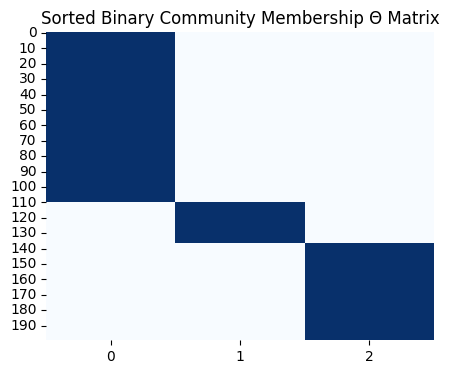

In [4]:
# Sort the Θ matrix by community assignments
sorted_indices = np.lexsort(Θ.T)
sorted_Θ = Θ[sorted_indices]

# Plot the sorted Θ matrix
plt.figure(figsize=(5, 4))
sns.heatmap(sorted_Θ, cmap='Blues', cbar=False)
plt.title("Sorted Binary Community Membership Θ Matrix")
plt.show()

In [5]:
# Given parameters
B = np.array([[0.9, 0.15, 0.25],
              [0.15, 0.75, 0.05],
              [0.25, 0.05, 0.6]])

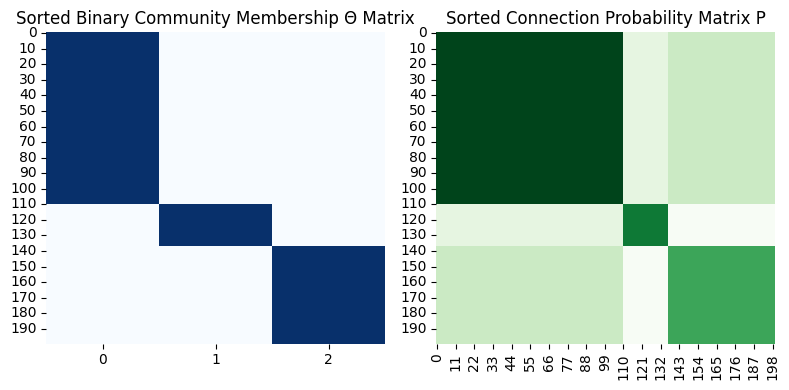

Values of interest in the sorted P matrix:
P[1, 3]: 0.9
P[197, 199]: 0.6
P[192, 4]: 0.25


In [6]:
# Create the connection probability matrix P
P = Θ @ B @ Θ.T

# Sort the Θ matrix and P matrix by community assignments
sorted_indices = np.lexsort(Θ.T)
sorted_Θ = Θ[sorted_indices]
sorted_P = P[sorted_indices][:, sorted_indices]

# Plot side-by-side visualizations of sorted Θ and sorted P matrices
plt.figure(figsize=(8, 4))

# Plot sorted Θ matrix
plt.subplot(1, 2, 1)
sns.heatmap(sorted_Θ, cmap='Blues', cbar=False)
plt.title("Sorted Binary Community Membership Θ Matrix")

# Plot sorted P matrix
plt.subplot(1, 2, 2)
sns.heatmap(sorted_P, cmap='Greens', cbar=False)
plt.title("Sorted Connection Probability Matrix P")

plt.tight_layout()
plt.show()

# Report the values of interest
print("Values of interest in the sorted P matrix:")
print("P[1, 3]:", sorted_P[0, 2])
print("P[197, 199]:", sorted_P[196, 198])
print("P[192, 4]:", sorted_P[191, 3])

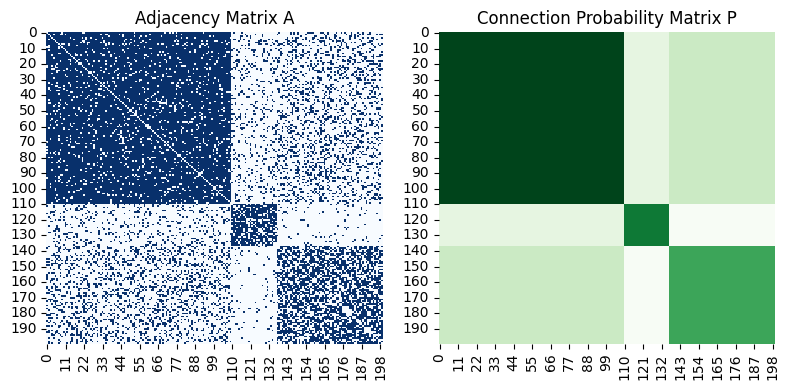

In [7]:
# Function to generate the adjacency matrix A from the connection probability matrix P
def generate_adjacency_matrix(P):
    n = P.shape[0]
    A = np.zeros((n, n), dtype=int)
    for i in range(n):
        for j in range(i + 1, n):
            if i != j:
                A[i, j] = np.random.binomial(1, P[i, j])
                A[j, i] = A[i, j]  # Since it's an undirected graph
    return A

# Generate the adjacency matrix A
A = generate_adjacency_matrix(sorted_P)

# Plot side-by-side visualizations of A and P matrices
plt.figure(figsize=(8, 4))

# Plot A matrix
plt.subplot(1, 2, 1)
sns.heatmap(A, cmap='Blues', cbar=False)
plt.title("Adjacency Matrix A")

# Plot P matrix
plt.subplot(1, 2, 2)
sns.heatmap(sorted_P, cmap='Greens', cbar=False)
plt.title("Connection Probability Matrix P")

plt.tight_layout()
plt.show()

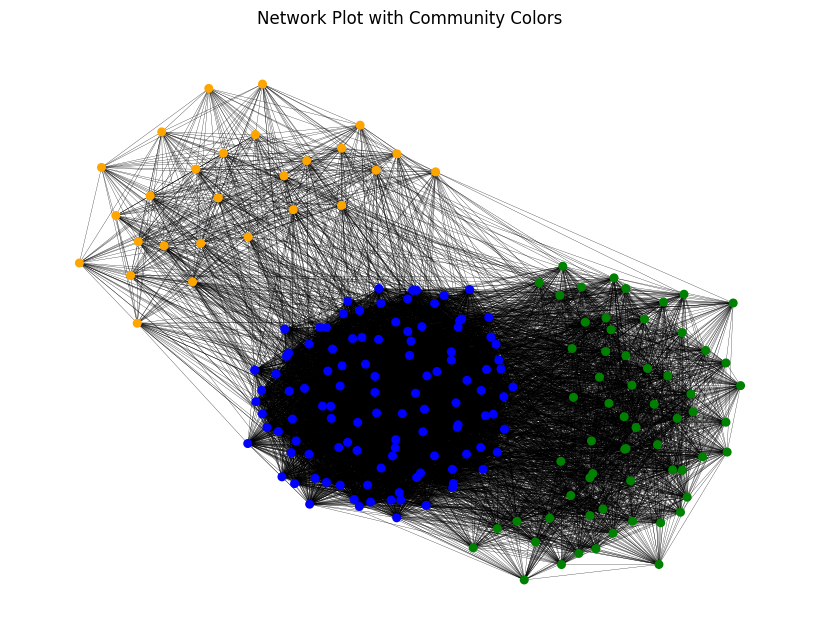

In [9]:
np.random.seed(1)
import networkx as nx

# Create a NetworkX graph from the adjacency matrix A
G = nx.from_numpy_array(A)

# Assign node colors based on the community membership in Θ
node_colors = ['blue' if sorted_Θ[i, 0] == 1 else 'orange' if sorted_Θ[i, 1] == 1 else 'green' for i in range(n)]

# Plot the network with community colors
plt.figure(figsize=(8, 6))
nx.draw(G, with_labels=False, node_size=30, width=0.2, node_color=node_colors)
plt.title("Network Plot with Community Colors")
plt.show()